In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [165]:
%matplotlib inline

In [166]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [167]:
df


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

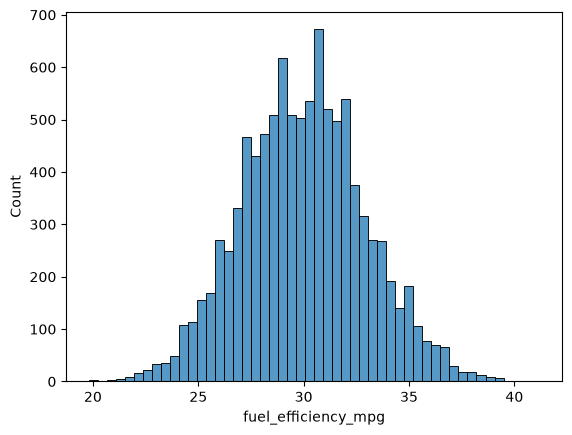

In [168]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [169]:
base = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
]

In [170]:
isnull = df[base].isnull().sum()

In [171]:
isnull

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
dtype: int64

In [172]:
mediana = df['horsepower'].median()

In [173]:
mediana

np.float64(254.0)

In [174]:
base


['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [175]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [176]:
def include_seed(seed):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train : n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val :]].copy()

    df_train = df_train.reset_index(drop=True) 
    df_val = df_val.reset_index(drop=True) 
    df_test = df_test.reset_index(drop=True) 

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    return df_train, df_val, df_test, y_train, y_val, y_test

In [177]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

def prepare_X(df, fill):
    features = base.copy()
    df_num = df[features]
    df_num = df_num.fillna(fill)
    X = df_num.values
    return X

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def get_rmse_result(train_df, y_train, rmse_df, y_rmse, fill):
    X_train = prepare_X(train_df, fill=fill)
    X_rmse = prepare_X(rmse_df, fill=fill)
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_rmse.dot(w)
    rmse_result = rmse(y_rmse, y_pred)
    
    return rmse_result

def get_rmse_result_reg(train_df, y_train, rmse_df, y_rmse, fill, r):
    X_train = prepare_X(train_df, fill=fill)
    X_rmse = prepare_X(rmse_df, fill=fill)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_rmse.dot(w)
    rmse_result = rmse(y_rmse, y_pred)
    
    return rmse_result

In [178]:
df_train, df_val, df_test, y_train, y_val, y_test = include_seed(42)
horsepower_mean = df_train['horsepower'].mean()
rmse_0 = get_rmse_result(df_train, y_train, df_val, y_val, fill=0)
rmse_mean = get_rmse_result(df_train, y_train, df_val, y_val, fill=horsepower_mean)
rmse_0 = round(rmse_0, 3)
rmse_mean = round(rmse_mean, 3)

In [179]:
rmse_0, rmse_mean


(np.float64(2.205), np.float64(2.202))

In [180]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


In [181]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    df_train, df_val, df_test, y_train, y_val, y_test = include_seed(42)
    rmse_score = get_rmse_result_reg(df_train, y_train, df_val, y_val, fill=0, r=r)
    
    print(r, round( rmse_score, 4 ))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [182]:
scores = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = include_seed(seed)
    rmse_score = get_rmse_result(df_train, y_train, df_val, y_val, fill=0)
    scores.append(rmse_score)

std_result = round( np.std(scores),3 )

In [183]:
std_result

np.float64(0.029)

In [184]:
df_train, df_val, df_test, y_train, y_val, y_test = include_seed(9)

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X(df_full_train, fill=0)
X_test = prepare_X(df_test, fill=0)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

y_pred = w0 + X_test.dot(w)

score2 = round(rmse(y_test, y_pred), 3)

In [185]:
score2

np.float64(2.236)